# <center>Rozwiązywanie układów równań</center>

Instrukcja:
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi (w postaci kodu) z komentarzami w środowisku Jupyter Notebook i umieścić je na platformie e-learningowej.   

In [105]:
import main
import scipy as sp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from timeit import timeit

%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


**Cel zajęć:** Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania układów równań liniowych w postaci macierzowej, z rzadkimi macierzami prostokątnymi. Czyli dana jest macierz $\mathbf{A}$ prostokątna o wymiarach ($m\times n$) i [rzadka](https://pl.wikipedia.org/wiki/Macierz_rzadka) oraz wektor $\mathbf{b}$ ($m\times 1$), należy rozwiązać układ równań postaci:    
$
\mathbf{Ax}=\mathbf{b}
$ 
  
gdzie $\mathbf{A}$ to macierz współczynników z lewej strony równania, wektor $\mathbf{x}$ jest wektorem zmiennych a wektor $\mathbf{b}$ wyników prawej strony równania.  

Do oceny jakości rozwiązania będziemy wykorzystywać residuum (ang. *residual*)
$
\mathbf{r}=\mathbf{b}-\mathbf{Ax}
$ 
  

***Zadanie 1***   
Dane jest $m = 50$ oraz $n = 12$. Zdefiniuję funkcję *spare_matrixAbt*, która zwróci:
- wektor $\mathbf{t}$ typu $m\times 1$ za pomocą komendy linspace tak aby wartości tego wektora należay do przedzaiłu $[0,1]$,
- wektor $\mathbf{b}$ typu $m \times 1$, którego wartości dane są funkcją $\cos(4t)$ oraz
- macierz $\mathbf{A}$ postaci: 
$$
\left[\begin{matrix}
1 & t_0 & t_{0}^{2} & \cdots & t_{0}^{n-1} \\
1 & t_1 & t_{1}^{2} & \cdots & t_{1}^{n-1} \\
1 & t_2 & t_{2}^{2} & \cdots & t_{2}^{n-1} \\
\vdots & \cdots & \ddots & \cdots & \vdots \\
1 & t_{m-1} & t_{m-1}^{2} & \cdots & t_{m-1}^{n-1} 
\end{matrix}\right]
$$  
  
**Wskazówka**: Do definicji macierzy $\mathbf{A}$ należy użyć funkcji [vander](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.vander.html) oraz [fliplr](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.fliplr.html).  
 
  
Rozwiąż układ równań $\mathbf{Ax}=\mathbf{b}$ postaci:
$$
\left[\begin{matrix}
1 & t_0 & t_{0}^{2} & \cdots & t_{0}^{n-1} \\
1 & t_1 & t_{1}^{2} & \cdots & t_{1}^{n-1} \\
1 & t_2 & t_{2}^{2} & \cdots & t_{2}^{n-1} \\
\vdots & \cdots & \ddots & \cdots & \vdots \\
1 & t_{m-1} & t_{m-1}^{2} & \cdots & t_{m-1}^{n-1} 
\end{matrix}\right]
\left[\begin{matrix}
x_0\\
x_1\\
x_2\\
\vdots\\
x_{n-1}
\end{matrix}\right] =
\left[\begin{matrix}
b_0\\
b_1\\
b_2\\
\vdots\\
b_{m-1}
\end{matrix}\right]
$$ 
za pomocą następujacych metod:

1. Przekształcenia układu równań do postaci: $\mathbf{A}^{\mathrm{T}}\mathbf{Ax}=\mathbf{A}^{\mathrm{T}}\mathbf{b}$ (zdefinuj funkcję *square_from_rectan* która przekształci odpowiednio macierz A i wektor b)  i stosując funkcję solve, z poprzednich zajęć.
2. Domyślnej metody Pythona rozwiązywania układów równań z macierzą prostokątną [lstsq](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.linalg.lstsq.html#numpy-linalg-lstsq).  
3. Rozkładu QR rozwiązywania układów równań podanego na wykładzie. Do dokonania rozkładu QR w Pythonie używa się funkcji [qr](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.qr.html), natomiast do rozwiązywania układu równań z macierzą trójkątną służy funkcja [solve_triangular](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html)
4. Metody rozkładu SVD rozwiązywania układów równań podanego na wykładzie.
5. Porównaj czasy wykonania wszystkich metod oraz zużycie pamięci.
6. Porównaj jakość otrzymanych wyników

[2.6636896340272493e-08, 7.999155756306485e-09, 7.999154952320481e-09, 7.999154452290661e-09]
rectangle
17.3 µs ± 2.34 µs per loop (mean ± std. dev. of 10 runs, 10 loops each)
lstsq
44 µs ± 9.35 µs per loop (mean ± std. dev. of 10 runs, 10 loops each)
qr
81 µs ± 37.2 µs per loop (mean ± std. dev. of 10 runs, 10 loops each)
SVD
63.3 µs ± 9.2 µs per loop (mean ± std. dev. of 10 runs, 10 loops each)
rectangle
peak memory: 111.34 MiB, increment: 0.01 MiB
lstsq
peak memory: 111.34 MiB, increment: 0.00 MiB
qr
peak memory: 111.34 MiB, increment: 0.00 MiB
SVD
peak memory: 111.34 MiB, increment: 0.00 MiB


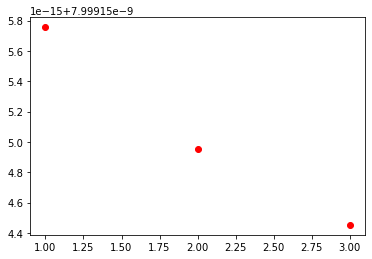

In [106]:
"""Funkcje znajdują się na końcu main'a"""
norm=[]

A,b=main.spare_matrix_Abt(m=50, n=12)

norm.append(main.residual_norm(A,main.rectangle(A,b),b))
norm.append(main.residual_norm(A,main.lstsq(A,b),b))
norm.append(main.residual_norm(A,main.qr(A,b),b))
norm.append(main.residual_norm(A,main.SVD(A,b),b))
print(norm)
plt.plot([1,2,3],norm[1:],'ro')
plt.title='norma'
print('rectangle')
%timeit -r 10 -n 10 main.rectangle(A,b)
print('lstsq')
%timeit -r 10 -n 10 main.lstsq(A,b)
print('qr')
%timeit -r 10 -n 10 main.qr(A,b)
print('SVD')
%timeit -r 10 -n 10 main.SVD(A,b)

print('rectangle')
%memit main.rectangle(A,b)
print('lstsq')
%memit main.lstsq(A,b)
print('qr')
%memit main.qr(A,b)
print('SVD')
%memit main.SVD(A,b)

Wyniki są następujące porządkując rosnąco po czasie i pamięci oraz malejąco po normie

Czas :   Rectangle,lstsq,SVD,qr

Pamięć : Rectangle,lstsq,qr,SVD

Norma :  SVD,qr,lstsq,Rectangle

Przy czym norma dla metody użytej w Rectangle była znacząco większa od tej dla pozostałych
 Dochodzę zatem do wniosku że domyślnie opłaca się używać metody lstsq będącej kompromisem między czasem, pamięcią a precyzją.
 Jeśli zależy nam na precyzji najlepiej wybrać SVD, jeśli przeviwnie Rectangle.

***Zadanie 2***  

1. Przy użyciu funkcji [random.normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html) wygeneruj dwa wektory $\mathbf{x}_1$ oraz $\mathbf{x}_2$ o wymiarze (100,1) o wartości średniej równej 0 oraz odchyleniu standardowemu równego 1.

2. Na podstawie uzyskanych wektorów wylicz wartości wektora $y$ danego wzorem:
$$
    y=2+x1-0.5x2+\epsilon
$$
gdzie $\epsilon$ jest wektorem wartości losowtch o wartości średniej równej 0 oraz odchyleniu standardowemu równego 1.

3. Przy pomocy funkcji [concatenate](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html) połącz wektor samych jedynek o wymiarze (100,1) z:

- $x_1$,
- $x_2$,
- $x_1$ i $x_2$

z parametrem *axis = 1*.

4. Na podstawie macierzy z punktu 3 oblicz współczynniki [regresji liniowych](https://pl.wikipedia.org/wiki/Regresja_liniowa) z wykorzystaniem rozkładu QR, opisanych zależnościami:

    1. $y\sim a+x_1$
    2. $y\sim a+x_2$
    3. $y\sim a+x_1+x_2$
    4. $y\sim a+x_2+x_2$

5. Przedstaw otrzymane wyniki na odpowiednich subplotach.

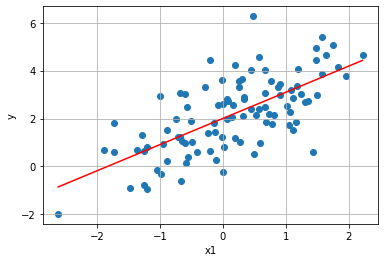

In [107]:
x1=np.random.normal(loc=0.0, scale=1.0, size=(100,1))
x2=np.random.normal(loc=0.0, scale=1.0, size=(100,1))
e=np.random.normal(loc=0.0, scale=1.0, size=(100,1))
y=2+x1-0.5*x2+e
j=np.ones((100,1))
ex1=np.concatenate((j,x1),1)
ex2=np.concatenate((j,x2),1)
ex1x2=np.concatenate((j,x1,x2),1)
ex2x2=np.concatenate((j,x2,x2),1)

q,r=np.linalg.qr(ex1)
s=sp.linalg.solve_triangular(r,q.T@y)
pred1=[min(x1), max(x1)]
y1=s[0]+s[1]*pred1

plt.scatter(x1,y)
plt.plot(pred1,y1, "r")
plt.grid()
plt.xlabel("x1")
plt.ylabel("y")
plt.show()

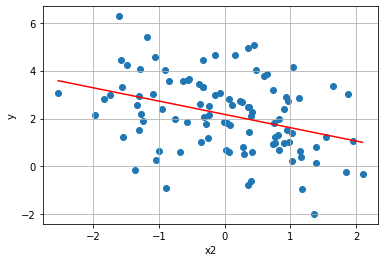

In [108]:
q,r=np.linalg.qr(ex2)
s=sp.linalg.solve_triangular(r,q.T@y)
pred1=[min(x2), max(x2)]
y1=s[0]+s[1]*pred1

plt.scatter(x2,y)
plt.plot(pred1,y1, "r")
plt.grid()
plt.xlabel("x2")
plt.ylabel("y")
plt.show()

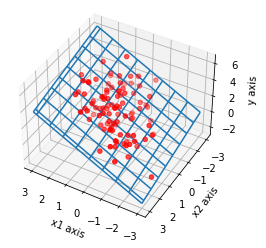

In [109]:
q, r = np.linalg.qr(ex1x2)
s = sp.linalg.solve_triangular(r, q.T @ y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1,x2,y, c='r', marker="o")

ax.set_xlabel("x1 axis")
ax.set_ylabel("x2 axis")
ax.set_zlabel("y axis")

ox,oy = np.meshgrid(np.linspace(-3,3,100), np.linspace(-3,3,100))
z = s[0] + s[1] * ox + s[2] * oy
ax.plot_wireframe(ox,oy, z, rstride = 12, cstride = 12)

ax.view_init(40,120)
plt.show()

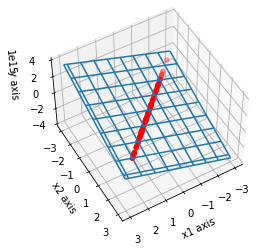

In [110]:
q, r = np.linalg.qr(ex2x2)
s = sp.linalg.solve_triangular(r, q.T @ y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x2,x2,y, c='r', marker="o")

ax.set_xlabel("x1 axis")
ax.set_ylabel("x2 axis")
ax.set_zlabel("y axis")

ox,oy = np.meshgrid(np.linspace(-3,3,100), np.linspace(-3,3,100))
z = s[0] + s[1] * ox + s[2] * oy
ax.plot_wireframe(ox,oy, z, rstride = 12, cstride = 12)

ax.view_init(50,60)
plt.show()

Materiały uzupełniające:
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)